In [13]:
INPUT_DATA_DIR = '../../data/'
PICKLES_DIR = './pickles/'
OUTPUT_PREDS_DIR = './predictions/'


As a result of the feature selection process, we concluded that the ranking produced by Random Forest, was most robus and therefore we will continue using it for future analyses. Some preliminary tests showed that the top four features from that ranking were truly most effective (considering the cost of adding new variables).

#### imports and helper functions

In [14]:
import itertools
import time
import random
import gc

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import joblib

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [15]:
import warnings
warnings.filterwarnings('ignore')

#### scoring function definition

In [16]:
def calculate_optimal_business_score(y_true, y_probs, k_features, max_contacts=1000, 
                                    threshold=0.33, tp_reward=10, fp_penalty=5, 
                                    feature_cost=200):
    """
    Calculates score based on a fixed probability threshold (0.33), 
    capped by a maximum contact limit.
    """
    qualified_indices = np.where(y_probs >= threshold)[0]

    qualified_probs = y_probs[qualified_indices]
    sorted_order = np.argsort(qualified_probs)[::-1]
    sorted_indices = qualified_indices[sorted_order]
    
    final_indices = sorted_indices[:max_contacts]
    
    y_true_arr = y_true.values if isinstance(y_true, (pd.Series, pd.DataFrame)) else y_true
    selected_y_true = y_true_arr[final_indices]
    
    tps = np.sum(selected_y_true == 1)
    fps = np.sum(selected_y_true == 0)
    
    total_profit = (tps * tp_reward) - (fps * fp_penalty)
    final_score = total_profit - (k_features * feature_cost)
    
    return final_score, total_profit, len(final_indices)

#### loading data from previous phase

In [17]:
gc.collect()

data_x_raw = pd.read_csv(f'{INPUT_DATA_DIR}x_train.txt', sep=r'\s+')
data_y = pd.read_csv(f'{INPUT_DATA_DIR}y_train.txt', sep=r'\s+')
if isinstance(data_y, pd.DataFrame) and data_y.shape[1] == 1:
    data_y = data_y.iloc[:, 0]

dropped_cols = joblib.load(f'{PICKLES_DIR}dropped_collinear_features.pkl')
final_top_k_features = joblib.load(f'{PICKLES_DIR}final_top_k_features.pkl')

data_x = data_x_raw.drop(columns=dropped_cols, errors='ignore')

#### SVM preliminary test 
During previous runs, there were some promising results when using the SVM model, the top result is replicated below. The evaluation is calculated based on out-of-fold probabilities in a 5 fold crossvalidation.

##### helper functions

In [ ]:
def train_and_evaluate_svm(data_x, data_y, feature_subset, 
                                     filename='train_oof_probabilities_svm.csv',
                                     max_contacts=1000, threshold=0.33, 
                                     tp_reward=10, fp_penalty=5, feature_cost=200):
    """
    Trains an SVM, calculates OOF probabilities, saves them to CSV, 
    and returns the business metrics.
    """
    k = len(feature_subset)
    
    # 1. Pipeline and CV setup
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(probability=True, class_weight='balanced', 
                    random_state=42, max_iter=20000, cache_size=4000))
    ])
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # 2. Generate OOF Probabilities
    X_subset = data_x[feature_subset]
    oof_probs = cross_val_predict(
        pipeline, X_subset, data_y, 
        cv=skf, method='predict_proba', n_jobs=1
    )[:, 1]
    
    # 3. Save OOF probabilities to CSV
    train_output_df = pd.DataFrame({
        'index': data_x.index,
        'true_label': data_y,
        'predicted_probability': oof_probs
    })
    train_output_df.to_csv(f"{OUTPUT_PREDS_DIR}{filename}", index=False)
    print(f"\nTraining OOF probabilities saved to '{filename}'.")
    
    # 4. Calculate Business Score
    net_profit, gross_profit, contacts = calculate_optimal_business_score(
        data_y, oof_probs, k_features=k, max_contacts=max_contacts,
        threshold=threshold, tp_reward=tp_reward, 
        fp_penalty=fp_penalty, feature_cost=feature_cost
    )
    
    return net_profit, gross_profit, contacts

def process_test_set_SVM(data_x, data_y, test_x_path, feature_subset, 
                     threshold=0.33, tp_reward=10, fp_penalty=5, feature_cost=200):
    """
    Trains on full training set and evaluates/saves predictions on test set.
    """
    k = len(feature_subset)
    print(f"\nTraining final model on {k} features and evaluating test set...")

    test_x_raw = pd.read_csv(test_x_path, sep=r'\s+')
    test_x = test_x_raw[feature_subset]
    
    final_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(probability=True, class_weight='balanced', 
                    random_state=42, max_iter=20000, cache_size=4000))
    ])
    
    final_pipeline.fit(data_x[feature_subset], data_y)
    
    test_probs = final_pipeline.predict_proba(test_x)[:, 1]
    
    test_output_df = pd.DataFrame({
        'index': np.arange(len(test_probs)),
        'predicted_probability': test_probs
    })
    test_output_df.to_csv(f"{OUTPUT_PREDS_DIR}test_predictions_svm.csv", index=False)

    print(f"Test set predictions saved to {OUTPUT_PREDS_DIR}test_predictions_svm.csv.")
    
    return test_probs

##### Evaluation
Since it is a result superior to any of other models trained by the pipeline, we save the train and test predictions

In [19]:
chosen_features = final_top_k_features[:4]
net_p, gross_p, n_contacts = train_and_evaluate_svm(data_x, data_y, chosen_features)

print(f"\nNet Profit on training set with chosen features: €{net_p:,.1f}")

test_probs = process_test_set_SVM(
    data_x, data_y, 
    f'{INPUT_DATA_DIR}x_test.txt', 
    chosen_features)


Training OOF probabilities saved to 'train_oof_probabilities.csv'.

Net Profit on training set with chosen features: €5,405.0

Training final model on 4 features and evaluating test set...
Test set predictions saved to ./predictions/test_predictions_svm.csv.


#### Data Exploration - continuation
We decided to take a closer look at the top 4 selected features and plot the data on a 3d axis to see if there would be some natural clusters or other structural attributes that would help us find and visualise the solution

##### helper

In [20]:
def plot_3d_feature_subsets(data_x, data_y, features):
    fig = plt.figure(figsize=(10, 15))
    fig.suptitle('3D feature distribution (orange=1, blue=0)', fontsize=16, y=0.98)

    for i, exclude_feat in enumerate(features):
        remaining_features = [f for f in features if f != exclude_feat]
        ax = fig.add_subplot(2, 2, i + 1, projection='3d')

        mask_1 = (data_y == 1)
        mask_0 = (data_y == 0)

        ax.scatter(data_x.loc[mask_0, remaining_features[0]],
                   data_x.loc[mask_0, remaining_features[1]],
                   data_x.loc[mask_0, remaining_features[2]],
                   c='steelblue', s=5, alpha=0.5)

        ax.scatter(data_x.loc[mask_1, remaining_features[0]],
                   data_x.loc[mask_1, remaining_features[1]],
                   data_x.loc[mask_1, remaining_features[2]],
                   c='darkorange', s=5, alpha=0.2)

        ax.set_title(f'exclude {exclude_feat}', fontsize=13, pad=12)
        ax.set_xlabel(remaining_features[0], fontsize=12, labelpad=20)
        ax.set_ylabel(remaining_features[1], fontsize=12, labelpad=20)
        ax.set_zlabel(remaining_features[2], fontsize=12, labelpad=20)
        ax.tick_params(axis='both', which='major', labelsize=10)

        ax.zaxis.set_rotate_label(False)
        ax.zaxis.label.set_rotation(90)

    plt.show()

##### Plotted data
We observe that the distribution of data looks like some kind of gaussian distribution. Therefore we check if the QDA will work, if so, we could just use that simple model, which would already most likely be well-calibrated instead of the computationally expensive pipeline.

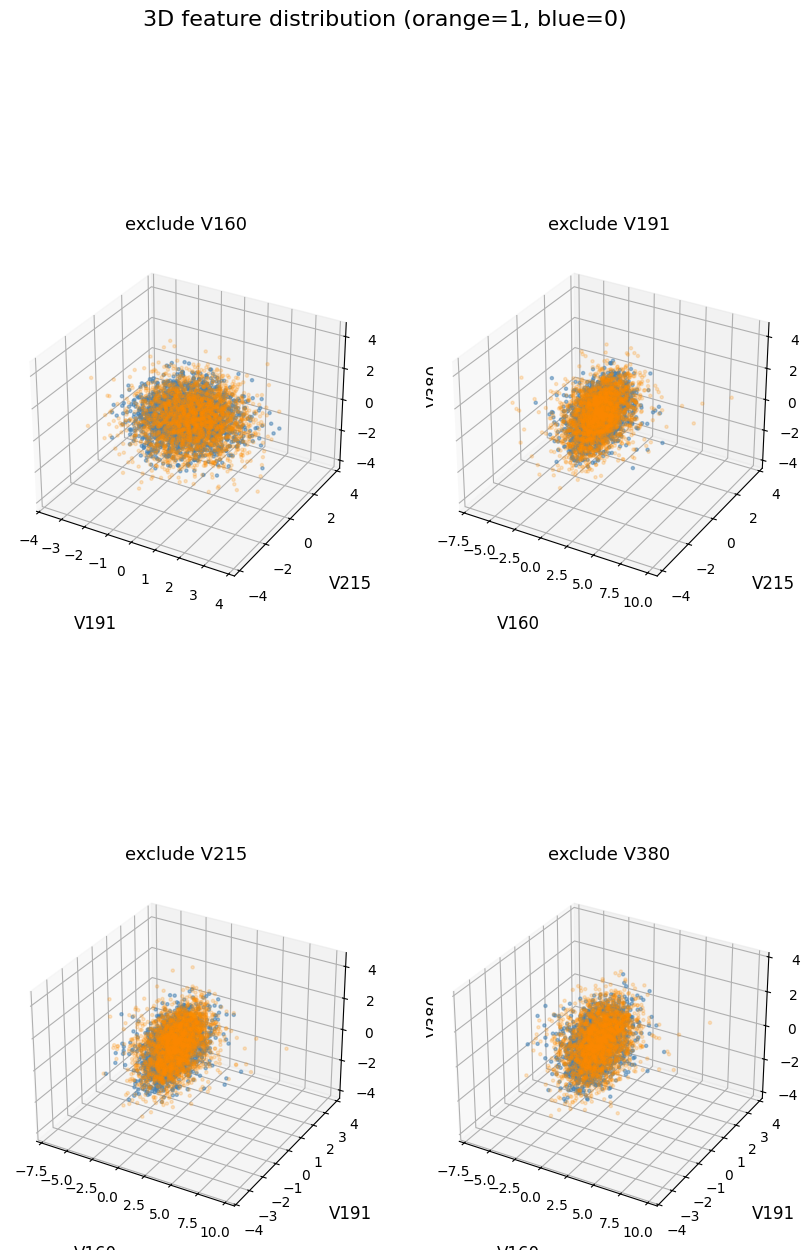

In [21]:
plot_3d_feature_subsets(data_x, data_y, chosen_features)

#### QDA - final single model
We first test it on the already established ranking, starting from the most important feature, we add them until there is no more profit.

In [22]:
y_flat = np.ravel(data_y)

models = {'QDA': QuadraticDiscriminantAnalysis()}

k_values_to_test = [1, 2, 3, 4, 5, 6]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_net_profit = -np.inf
best_config = None

print("\n--- Starting Evaluation Loop for QDA ---\n")
total_start_time = time.time()

for model_name, model in models.items():
    print(f"Evaluating {model_name}...")
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', model)
    ])
    
    for k in k_values_to_test:
        start_time_k = time.time()
        
        X_subset = data_x[final_top_k_features[:k]]
        
        try:
            oof_probs = cross_val_predict(
                pipeline, X_subset, y_flat, 
                cv=skf, method='predict_proba', n_jobs=1
            )[:, 1]

            net_profit, gross_profit, contacts = calculate_optimal_business_score(
                y_flat, oof_probs, k_features=k, max_contacts=1000,
                tp_reward=10, fp_penalty=5, feature_cost=200
            )
            
            print(f"  [{model_name} K={k}] Finished in {(time.time() - start_time_k):.1f} seconds.")
            print(f"    -> Gross Profit: €{gross_profit:,.1f} | Feature Cost: €{k*200:,.1f}")
            print(f"    -> Net Profit (Score): €{net_profit:,.1f} | Contacts: {contacts}")
            
            if net_profit > best_net_profit:
                best_net_profit = net_profit
                best_config = {
                    'model': model_name,
                    'k': k,
                    'gross': gross_profit,
                    'contacts': contacts,
                    'cost': k * 200
                }
                
        except Exception as e:
            print(f"  [ERROR] at {model_name} K={k}: {type(e).__name__} - {e}")
            
    print("-" * 50)

print(f"==================================================")
if best_config:
    print(f" WINNER: {best_config['model']} with K = {best_config['k']} (Highest Net Profit)")
    print(f"==================================================")
    print(f" Optimal Calls Made : {best_config.get('contacts', 0)}")
    print(f" Gross Profit       : €{best_config.get('gross', 0):,.1f}")
    print(f" Feature Cost       : €{best_config.get('cost', 0):,.1f}")
    print(f"--------------------------------------------------")
    print(f" FINAL NET PROFIT   : €{best_net_profit:,.1f}")
print(f"==================================================")
print(f"Total time elapsed: {(time.time() - total_start_time) / 60:.1f} minutes.")


--- Starting Evaluation Loop for QDA ---

Evaluating QDA...
  [QDA K=1] Finished in 0.1 seconds.
    -> Gross Profit: €4,750.0 | Feature Cost: €200.0
    -> Net Profit (Score): €4,550.0 | Contacts: 1000
  [QDA K=2] Finished in 0.1 seconds.
    -> Gross Profit: €5,215.0 | Feature Cost: €400.0
    -> Net Profit (Score): €4,815.0 | Contacts: 1000
  [QDA K=3] Finished in 0.1 seconds.
    -> Gross Profit: €5,515.0 | Feature Cost: €600.0
    -> Net Profit (Score): €4,915.0 | Contacts: 1000
  [QDA K=4] Finished in 0.1 seconds.
    -> Gross Profit: €5,875.0 | Feature Cost: €800.0
    -> Net Profit (Score): €5,075.0 | Contacts: 1000
  [QDA K=5] Finished in 0.1 seconds.
    -> Gross Profit: €6,055.0 | Feature Cost: €1,000.0
    -> Net Profit (Score): €5,055.0 | Contacts: 1000
  [QDA K=6] Finished in 0.1 seconds.
    -> Gross Profit: €6,175.0 | Feature Cost: €1,200.0
    -> Net Profit (Score): €4,975.0 | Contacts: 1000
--------------------------------------------------
 WINNER: QDA with K = 4 (H

This in itself is a satisfactory profit, compared with previously tested baselines which continuously scored below 5000, but not yet as good as the SVM. But this feature ranking method was not specifically tailored to the QDA algorithm, so we try again with a standard forward selection.

##### forward selection

In [23]:

def forward_selection_qda(X, y, max_features=10):
    available_features = list(X.columns)
    selected_features = []
    
    best_overall_score = -np.inf
    best_overall_stats = None
    
    print(f"--- Starting Forward Selection with QDA ({len(available_features)} initial features) ---\n")
    total_start_time = time.time()

    for step in range(1, max_features + 1):
        print(f"Step {step}: Searching for the best next feature...")
        step_start_time = time.time()
        
        best_step_score = -np.inf
        best_step_feature = None
        best_step_stats = None
        
        for candidate in available_features:
            current_features = selected_features + [candidate]
            X_subset = X[current_features]
            
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('clf', QuadraticDiscriminantAnalysis())
            ])
            
            try:
                oof_probs = cross_val_predict(
                    pipeline, X_subset, y, 
                    cv=skf, method='predict_proba', n_jobs=-1
                )[:, 1]
                
                k = len(current_features)
                net_profit, gross_profit, contacts = calculate_optimal_business_score(
                    y, oof_probs, k_features=k, max_contacts=1000,
                    tp_reward=10, fp_penalty=5, feature_cost=200
                )

                if net_profit > best_step_score:
                    best_step_score = net_profit
                    best_step_feature = candidate
                    best_step_stats = {
                        'gross': gross_profit,
                        'contacts': contacts,
                        'cost': k * 200
                    }
                    
            except Exception as e:
                continue

        if best_step_feature is None:
            print("  [!] No valid features could be added (likely collinearity). Stopping.")
            break
            
        print(f"  -> Best candidate this step: '{best_step_feature}' (Net Profit: €{best_step_score:,.1f})")
        print(f"  -> Step evaluated in {(time.time() - step_start_time):.1f} seconds.")
        
        if best_step_score > best_overall_score:
            best_overall_score = best_step_score
            selected_features.append(best_step_feature)
            available_features.remove(best_step_feature)
            best_overall_stats = best_step_stats
            print(f"  -> [KEPT] '{best_step_feature}' added to the model. Current K={len(selected_features)}.\n")
        else:
            print(f"  -> [STOPPING CONDITION MET]")
            print(f"     Adding '{best_step_feature}' resulted in €{best_step_score:,.1f}.")
            print(f"     This is worse than our previous peak of €{best_overall_score:,.1f}.")
            print(f"     The €200 feature penalty now outweighs the predictive gain.\n")
            break
            
    print("==================================================")
    print(" FORWARD SELECTION COMPLETE")
    print("==================================================")
    print(f" Winning Features   : {selected_features} (K={len(selected_features)})")
    print(f" Optimal Calls Made : {best_overall_stats.get('contacts', 0)}")
    print(f" Gross Profit       : €{best_overall_stats.get('gross', 0):,.1f}")
    print(f" Feature Cost       : €{best_overall_stats.get('cost', 0):,.1f}")
    print(f"--------------------------------------------------")
    print(f" FINAL NET PROFIT   : €{best_overall_score:,.1f}")
    print("==================================================")
    print(f" Total time elapsed : {(time.time() - total_start_time) / 60:.1f} minutes.")
    
    return selected_features

##### forward selection execution

In [24]:
optimal_qda_features = forward_selection_qda(data_x, y_flat, max_features=10)

--- Starting Forward Selection with QDA (490 initial features) ---

Step 1: Searching for the best next feature...
  -> Best candidate this step: 'V160' (Net Profit: €4,550.0)
  -> Step evaluated in 44.6 seconds.
  -> [KEPT] 'V160' added to the model. Current K=1.

Step 2: Searching for the best next feature...
  -> Best candidate this step: 'V342' (Net Profit: €5,010.0)
  -> Step evaluated in 19.0 seconds.
  -> [KEPT] 'V342' added to the model. Current K=2.

Step 3: Searching for the best next feature...
  -> Best candidate this step: 'V380' (Net Profit: €5,215.0)
  -> Step evaluated in 19.3 seconds.
  -> [KEPT] 'V380' added to the model. Current K=3.

Step 4: Searching for the best next feature...
  -> Best candidate this step: 'V191' (Net Profit: €5,285.0)
  -> Step evaluated in 19.4 seconds.
  -> [KEPT] 'V191' added to the model. Current K=4.

Step 5: Searching for the best next feature...
  -> Best candidate this step: 'V32' (Net Profit: €5,265.0)
  -> Step evaluated in 19.8 secon

We were able to increase the profit by another 200 euro. But as this is a very greedy approach, we decided to add some randomness to see if there is any more we can extract from the model with this modification. Instead of always choosing the top first feature, we randomly choose between the first or second in each iteration.

##### randomized forward selection

In [25]:

def forward_selection_qda_randomized(X, y, max_features=10):
    available_features = list(X.columns)
    selected_features = []
    
    best_overall_score = -np.inf
    best_overall_stats = None
    
    print(f"--- Starting Randomized Forward Selection with QDA ({len(available_features)} initial features) ---\n")
    total_start_time = time.time()
    
    for step in range(1, max_features + 1):
        print(f"Step {step}: Searching for candidates and rolling the dice...")
        step_start_time = time.time()
        
        candidate_results = []
        
        for candidate in available_features:
            current_features = selected_features + [candidate]
            X_subset = X[current_features]
            
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('clf', QuadraticDiscriminantAnalysis())
            ])
            
            try:
                oof_probs = cross_val_predict(
                    pipeline, X_subset, y, 
                    cv=skf, method='predict_proba', n_jobs=-1
                )[:, 1]

                k = len(current_features)
                net_profit, gross_profit, contacts = calculate_optimal_business_score(
                    y, oof_probs, k_features=k, max_contacts=1000,
                    tp_reward=10, fp_penalty=5, feature_cost=200
                )
                
                candidate_results.append({
                    'feature': candidate,
                    'score': net_profit,
                    'stats': {
                        'gross': gross_profit,
                        'contacts': contacts,
                        'cost': k * 200
                    }
                })
                
            except Exception as e:
                continue
                
        if not candidate_results:
            print("  [!] No valid features could be added (likely collinearity). Stopping.")
            break
            
        candidate_results.sort(key=lambda x: x['score'], reverse=True)

        valid_candidates = [c for c in candidate_results if c['score'] > best_overall_score]
        
        selected_candidate = None

        if len(valid_candidates) >= 2:
            choice_index = random.choice([0, 1])
            selected_candidate = valid_candidates[choice_index]
            
            rank_str = "1st Best" if choice_index == 0 else "2nd Best"
            print(f"  -> [RANDOM CHOICE: {rank_str}] '{selected_candidate['feature']}' selected. (Net Profit: €{selected_candidate['score']:,.1f})")
            
        elif len(valid_candidates) == 1:
            selected_candidate = valid_candidates[0]
            print(f"  -> [ONLY ONE VALID] '{selected_candidate['feature']}' was the only feature to improve profit. (Net Profit: €{selected_candidate['score']:,.1f})")
            
        else:
            print(f"  -> [STOPPING CONDITION MET]")
            print(f"     Even the absolute best candidate ('{candidate_results[0]['feature']}', €{candidate_results[0]['score']:,.1f}) is worse than our peak of €{best_overall_score:,.1f}.")
            break

        best_overall_score = selected_candidate['score']
        best_overall_stats = selected_candidate['stats']
        feature_name = selected_candidate['feature']
        
        selected_features.append(feature_name)
        available_features.remove(feature_name)
        print(f"  -> Step {step} evaluated in {(time.time() - step_start_time):.1f} seconds. Current K={len(selected_features)}.\n")
            
    print("==================================================")
    print(" RANDOMIZED FORWARD SELECTION COMPLETE")
    print("==================================================")
    print(f" Winning Features   : {selected_features} (K={len(selected_features)})")
    if best_overall_stats:
        print(f" Optimal Calls Made : {best_overall_stats.get('contacts', 0)}")
        print(f" Gross Profit       : €{best_overall_stats.get('gross', 0):,.1f}")
        print(f" Feature Cost       : €{best_overall_stats.get('cost', 0):,.1f}")
    print(f"--------------------------------------------------")
    print(f" FINAL NET PROFIT   : €{best_overall_score:,.1f}")
    print("==================================================")
    print(f" Total time elapsed : {(time.time() - total_start_time) / 60:.1f} minutes.")
    
    return selected_features

##### randomized selection execution

In [ ]:
optimal_qda_features_random = forward_selection_qda_randomized(data_x, y_flat, max_features=10)


--- Starting Randomized Forward Selection with QDA (490 initial features) ---

Step 1: Searching for candidates and rolling the dice...
  -> [RANDOM CHOICE: 2nd Best] 'V11' selected. (Net Profit: €4,160.0)
  -> Step 1 evaluated in 11.7 seconds. Current K=1.

Step 2: Searching for candidates and rolling the dice...
  -> [RANDOM CHOICE: 2nd Best] 'V342' selected. (Net Profit: €4,620.0)
  -> Step 2 evaluated in 12.7 seconds. Current K=2.

Step 3: Searching for candidates and rolling the dice...
  -> [RANDOM CHOICE: 2nd Best] 'V191' selected. (Net Profit: €4,875.0)
  -> Step 3 evaluated in 12.5 seconds. Current K=3.

Step 4: Searching for candidates and rolling the dice...
  -> [RANDOM CHOICE: 1st Best] 'V215' selected. (Net Profit: €5,165.0)
  -> Step 4 evaluated in 13.1 seconds. Current K=4.

Step 5: Searching for candidates and rolling the dice...
  -> [RANDOM CHOICE: 2nd Best] 'V483' selected. (Net Profit: €5,275.0)
  -> Step 5 evaluated in 13.1 seconds. Current K=5.

Step 6: Searchin

As a result of this selection we got:


 Winning Features   : ['V11', 'V342', 'V191', 'V215', 'V483', 'V380'] (K=6)
 Optimal Calls Made : 1000
 Gross Profit       : €6,580.0
 Feature Cost       : €1,200.0
 FINAL NET PROFIT   : €5,380.0

 Total time elapsed : 1.5 minutes.

 This is a remarkably high result, considering the higher price of features (compared with the K=4 from previous runs). To see if we can reduce this cost, we fix the feature selected last ('V380') and run it with all four feature subsets of the remaining five features.

In [27]:
selected_6 = ['V11', 'V342', 'V191', 'V215', 'V483']
fixed_feature = 'V380'

combinations_of_4 = list(itertools.combinations(selected_6, 4))

print(f"--- Testing {len(combinations_of_4)} Combinations (K=5, fixed='{fixed_feature}') ---\n")

best_combo_score = -np.inf
best_combo_features = None
best_combo_stats = None

total_start_time = time.time()

for i, combo in enumerate(combinations_of_4, 1):
    test_features = list(combo) + [fixed_feature]
    
    print(f"[{i}/{len(combinations_of_4)}] Testing: {test_features} ...")
    start_time_combo = time.time()
    
    X_subset = data_x[test_features]
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', QuadraticDiscriminantAnalysis())
    ])
    
    try:
        oof_probs = cross_val_predict(
            pipeline, X_subset, y_flat, 
            cv=skf, method='predict_proba', n_jobs=-1
        )[:, 1]
   
        net_profit, gross_profit, contacts = calculate_optimal_business_score(
            y_flat, oof_probs, k_features=5, max_contacts=1000,
            tp_reward=10, fp_penalty=5, feature_cost=200
        )
        
        print(f"    -> Gross Profit: €{gross_profit:,.1f} | Net Profit: €{net_profit:,.1f} | Contacts: {contacts}")
        print(f"    -> Finished in {(time.time() - start_time_combo):.1f} seconds.\n")
        
        if net_profit > best_combo_score:
            best_combo_score = net_profit
            best_combo_features = test_features
            best_combo_stats = {
                'gross': gross_profit,
                'contacts': contacts,
                'cost': 5 * 200
            }
            
    except Exception as e:
        print(f"    -> [ERROR] Failed due to: {type(e).__name__} - {e}\n")

print("==================================================")
print(" COMBINATION SEARCH COMPLETE")
print("==================================================")
print(f" Winning Combo      : {best_combo_features}")
if best_combo_stats:
    print(f" Optimal Calls Made : {best_combo_stats.get('contacts', 0)}")
    print(f" Gross Profit       : €{best_combo_stats.get('gross', 0):,.1f}")
    print(f" Feature Cost       : €{best_combo_stats.get('cost', 0):,.1f}")
print(f"--------------------------------------------------")
print(f" FINAL NET PROFIT   : €{best_combo_score:,.1f}")
print("==================================================")
print(f"Total time elapsed: {(time.time() - total_start_time):.1f} seconds.")

--- Testing 5 Combinations (K=5, fixed='V380') ---

[1/5] Testing: ['V11', 'V342', 'V191', 'V215', 'V380'] ...
    -> Gross Profit: €6,310.0 | Net Profit: €5,310.0 | Contacts: 1000
    -> Finished in 0.0 seconds.

[2/5] Testing: ['V11', 'V342', 'V191', 'V483', 'V380'] ...
    -> Gross Profit: €6,310.0 | Net Profit: €5,310.0 | Contacts: 1000
    -> Finished in 0.0 seconds.

[3/5] Testing: ['V11', 'V342', 'V215', 'V483', 'V380'] ...
    -> Gross Profit: €6,250.0 | Net Profit: €5,250.0 | Contacts: 1000
    -> Finished in 0.0 seconds.

[4/5] Testing: ['V11', 'V191', 'V215', 'V483', 'V380'] ...
    -> Gross Profit: €6,325.0 | Net Profit: €5,325.0 | Contacts: 1000
    -> Finished in 0.0 seconds.

[5/5] Testing: ['V342', 'V191', 'V215', 'V483', 'V380'] ...
    -> Gross Profit: €6,415.0 | Net Profit: €5,415.0 | Contacts: 1000
    -> Finished in 0.0 seconds.

 COMBINATION SEARCH COMPLETE
 Winning Combo      : ['V342', 'V191', 'V215', 'V483', 'V380']
 Optimal Calls Made : 1000
 Gross Profit     

#### results
The maximum final net profit we were able to achieve is 5,415 euro with K=5, using ['V342', 'V191', 'V215', 'V483', 'V380'].

#### QDA assumptions verification
To verify the approprietness of our approach we use TESTS to verify that the QDA assumptions will be satsfied. This would also imply that the model is already well-calibrated.

In [28]:
features_to_keep = ['V342', 'V191', 'V215', 'V483', 'V380']
data_x = data_x_raw[features_to_keep]

df = pd.concat([data_x, data_y], axis=1)
target_col = data_y.name

##### Normality within classes


1. Testing Univariate Normality within Classes (Shapiro-Wilk Test)
Null hypothesis: Data is normally distributed (p > 0.05 indicates normality)

Class: 0
  Feature: V342  | W-Stat: 0.9991 | p-value: 2.4281e-01 | Fail to Reject Null (Normal)
  Feature: V191  | W-Stat: 0.9990 | p-value: 1.4562e-01 | Fail to Reject Null (Normal)
  Feature: V215  | W-Stat: 0.9991 | p-value: 2.2101e-01 | Fail to Reject Null (Normal)
  Feature: V483  | W-Stat: 0.9985 | p-value: 2.5028e-02 | Reject Null (Not Normal)
  Feature: V380  | W-Stat: 0.9993 | p-value: 4.4059e-01 | Fail to Reject Null (Normal)

Class: 1
  Feature: V342  | W-Stat: 0.9994 | p-value: 6.3790e-01 | Fail to Reject Null (Normal)
  Feature: V191  | W-Stat: 0.9990 | p-value: 2.0415e-01 | Fail to Reject Null (Normal)
  Feature: V215  | W-Stat: 0.9997 | p-value: 9.6694e-01 | Fail to Reject Null (Normal)
  Feature: V483  | W-Stat: 0.9994 | p-value: 5.9211e-01 | Fail to Reject Null (Normal)
  Feature: V380  | W-Stat: 0.9995 | p-value: 7.9650e-01 

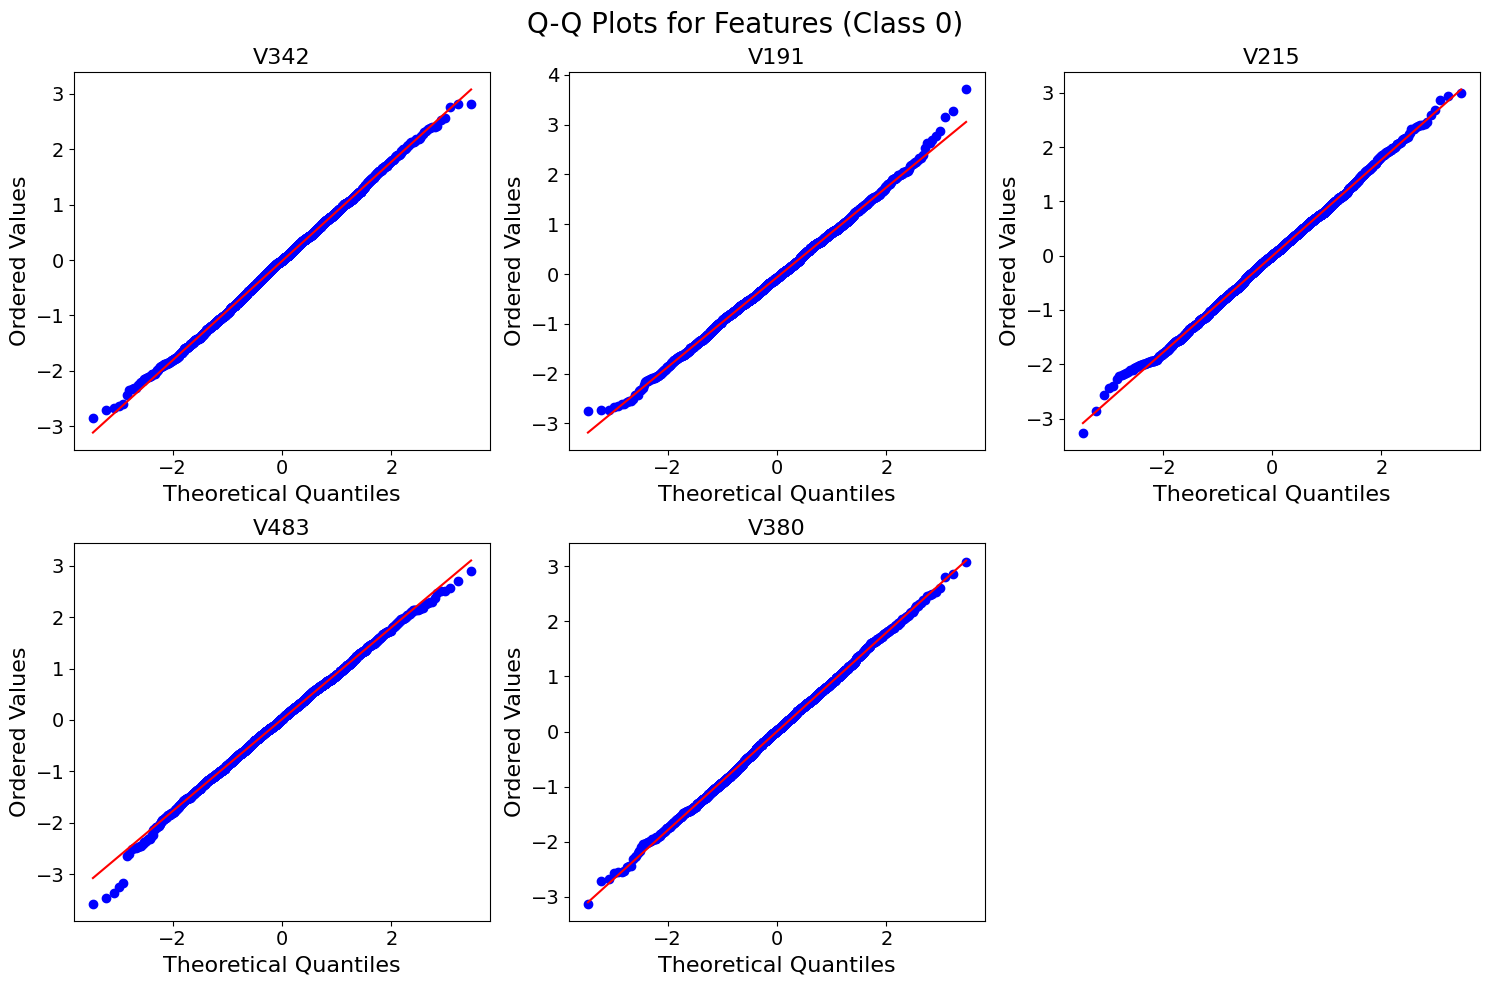

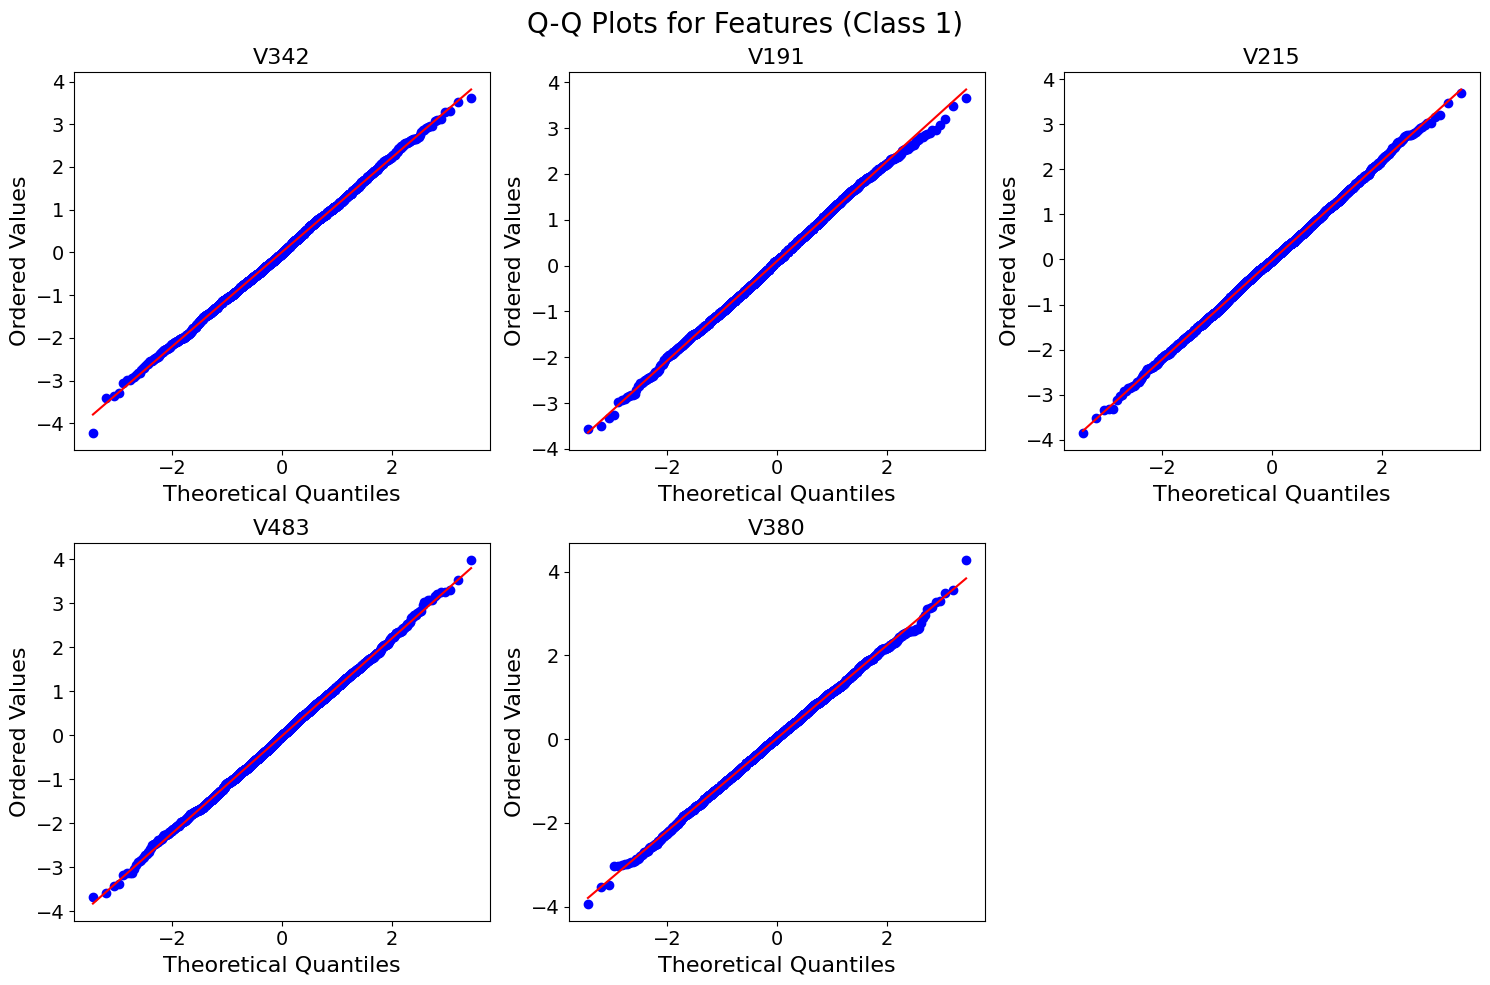

In [29]:
print("\n1. Testing Univariate Normality within Classes (Shapiro-Wilk Test)")
print("Null hypothesis: Data is normally distributed (p > 0.05 indicates normality)")

classes = df[target_col].unique()

for c in classes:
    print(f"\nClass: {c}")
    class_data = df[df[target_col] == c]
    
    for feature in features_to_keep:
        # The Shapiro-Wilk test is sensitive to large sample sizes (N > 5000)
        # If your class size is > 5000, consider taking a random sample of 5000 for the test.
        stat, p_value = stats.shapiro(class_data[feature].dropna())
        
        if p_value < 0.05:
            result = "Reject Null (Not Normal)"
        else:
            result = "Fail to Reject Null (Normal)"
            
        print(f"  Feature: {feature: <5} | W-Stat: {stat:.4f} | p-value: {p_value:.4e} | {result}")

# Visualizing Normality using Q-Q plots for the first class (as an example)

class_0_data = df[df[target_col] == classes[0]]

def plot_qq_class_data(class_data, features_to_keep, class_label=None):
    plt.figure(figsize=(15, 10))
    if class_label is not None:
        plt.suptitle(f"Q-Q Plots for Features (Class {class_label})", fontsize=20)
    else:
        plt.suptitle("Q-Q Plots for Features (Class )", fontsize=20)
    for i, feature in enumerate(features_to_keep, 1):
        ax = plt.subplot(2, 3, i)

        stats.probplot(class_data[feature].dropna(), dist="norm", plot=plt)

         # Title
        ax.set_title(feature, fontsize=16)

         # Axis labels (added by probplot)
        ax.set_xlabel("Theoretical Quantiles", fontsize=16)
        ax.set_ylabel("Ordered Values", fontsize=16)

         # Tick labels
        ax.tick_params(axis='both', labelsize=14)

    plt.tight_layout()
    plt.show()

plot_qq_class_data(class_0_data, features_to_keep, class_label = '0')
plot_qq_class_data(df[df[target_col] == classes[1]], features_to_keep, class_label = '1')

##### Multicollinearity / Singularity 
we removed most correlated variables earlier so this is quite obvious that it is satsfied


2. Testing for Multicollinearity and Singular Covariance Matrices
QDA requires that variables are not perfectly correlated within any class.

Class 0 Covariance Matrix Determinant: 3.3088e-01
  Determinant is non-zero. Matrix is invertible (Good for QDA).

Class 1 Covariance Matrix Determinant: 2.5358e+00
  Determinant is non-zero. Matrix is invertible (Good for QDA).


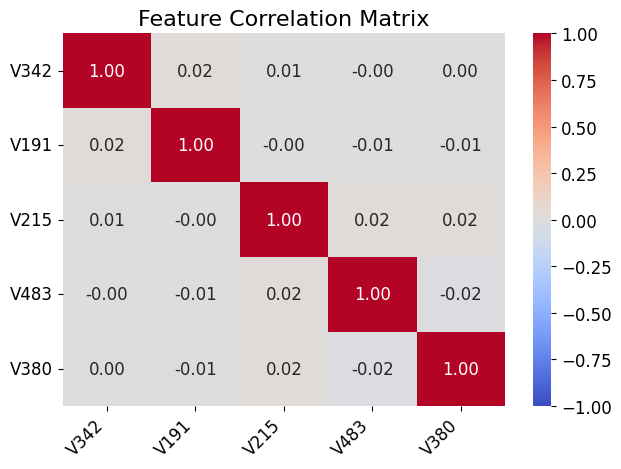

In [30]:
print("\n2. Testing for Multicollinearity and Singular Covariance Matrices")
print("QDA requires that variables are not perfectly correlated within any class.")

for c in classes:
    class_data = df[df[target_col] == c][features_to_keep]
    cov_matrix = np.cov(class_data, rowvar=False)
    det = np.linalg.det(cov_matrix)
    
    print(f"\nClass {c} Covariance Matrix Determinant: {det:.4e}")
    if np.isclose(det, 0.0):
        print("  WARNING: Determinant is extremely close to 0.")
        print("  This indicates severe multicollinearity. QDA may fail or be unstable.")
    else:
        print("  Determinant is non-zero. Matrix is invertible (Good for QDA).")

ax = sns.heatmap(
    data_x.corr(),
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt=".2f",
    annot_kws={"size": 12}
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)

plt.title("Feature Correlation Matrix", fontsize=16)
plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12, rotation=0)

plt.tight_layout()
plt.show()

#### finding maximum profit threshold
Theoretically, based on the scoring function, the expected maximum profit threshold should be determined by calculating the point at which the expected value of contacting a client becomes positive.By setting the expected profit formula $E(\text{Profit}) = P \times 10 - (1 - P) \times 5$ and solving for  
$E(\text{Profit}) > 10P - 5 + 5P$  
$15P > 5$  
$P > \frac{1}{3} \approx 0.3333$  
Therefore, to ensure each sent offer yields a positive return, you should only target clients with a predicted conversion probability $P$ greater than approximately 0.3333. We compare this with an empirical threshold calculated based on the curvature of profit on the training set.

In [31]:
final_features = ['V342', 'V191', 'V215', 'V483', 'V380']
print(f"Generating probabilities for QDA using features: {final_features}...")

X_subset = data_x[final_features]
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', QuadraticDiscriminantAnalysis())
])

oof_probs = cross_val_predict(
    pipeline, X_subset, y_flat, 
    cv=skf, method='predict_proba', n_jobs=-1
)[:, 1]

train_oof_probabilities_qda = pd.DataFrame({
    'index': data_x.index,
    'probability': oof_probs
})

train_oof_probabilities_qda.to_csv(f'{OUTPUT_PREDS_DIR}train_oof_probabilities_qda.csv', index=False)

def find_threshold_max_profit(y_true, y_probs, tp_reward=10, fp_penalty=5):
    sorted_indices = np.argsort(y_probs)[::-1]
    y_true_sorted = np.ravel(y_true)[sorted_indices]
    sorted_probs = y_probs[sorted_indices]
    
    tps = np.cumsum(y_true_sorted == 1)
    fps = np.cumsum(y_true_sorted == 0)
    
    cumulative_profits = (tps * tp_reward) - (fps * fp_penalty)
    best_idx = np.argmax(cumulative_profits)
    
    optimal_contacts = best_idx + 1
    optimal_threshold = sorted_probs[best_idx]
    max_profit = cumulative_profits[best_idx]
    
    return optimal_contacts, optimal_threshold, max_profit, cumulative_profits


profit_contacts, profit_thresh, max_profit, cum_profits = find_threshold_max_profit(y_flat, oof_probs, 10, 5)


sorted_probs_desc = np.sort(oof_probs)[::-1]
contacts_33_threshold = np.sum(sorted_probs_desc >= 0.3333) 

y_true_sorted = np.ravel(y_flat)[np.argsort(oof_probs)[::-1]]
cum_tps = np.cumsum(y_true_sorted == 1)

print("-" * 40)
print("--- Threshold Results ---")
print(f"Max Profit Threshold : {profit_contacts} contacts | P = {profit_thresh * 100:.2f}%")
print(f"Theoretical P=33.33% : {contacts_33_threshold} contacts")
print("-" * 40)

Generating probabilities for QDA using features: ['V342', 'V191', 'V215', 'V483', 'V380']...
----------------------------------------
--- Threshold Results ---
Max Profit Threshold : 4142 contacts | P = 35.34%
Theoretical P=33.33% : 4441 contacts
----------------------------------------


##### visualisation

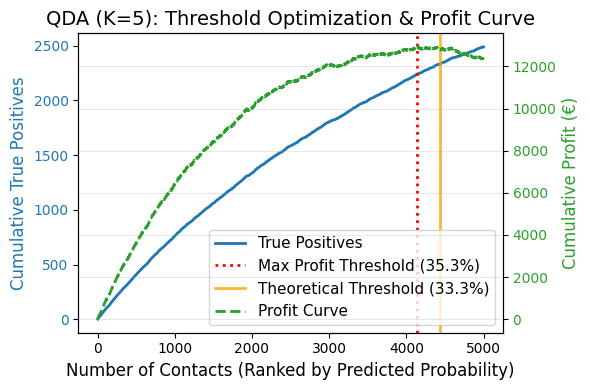

In [32]:
contacts_arr = np.arange(1, len(y_flat) + 1)

fig, ax1 = plt.subplots(figsize=(6, 4))

color1 = 'tab:blue'
ax1.set_xlabel('Number of Contacts (Ranked by Predicted Probability)', fontsize=12)
ax1.set_ylabel('Cumulative True Positives', color=color1, fontsize=12)
ax1.plot(contacts_arr, cum_tps, color=color1, linewidth=2, label='True Positives')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()  
color2 = 'tab:green'
ax2.set_ylabel('Cumulative Profit (€)', color=color2, fontsize=12)  
ax2.plot(contacts_arr, cum_profits, color=color2, linewidth=2, linestyle='--', label='Profit Curve')
ax2.tick_params(axis='y', labelcolor=color2)

ax1.axvline(x=profit_contacts, color='red', linestyle=':', linewidth=2,
            label=f'Max Profit Threshold ({profit_thresh * 100:.1f}%)')
ax1.axvline(x=contacts_33_threshold, color='orange', linestyle='-', linewidth=2, alpha=0.8,
            label=f'Theoretical Threshold (33.3%)')

plt.title("QDA (K=5): Threshold Optimization & Profit Curve", fontsize=14)
fig.tight_layout()

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower right', fontsize=11)

plt.grid(True, alpha=0.3)
plt.show()

As we see, the thresholds far exceed the  selections limit and therefore will have no efect on the final selection unless there is a major imbalance of classes on the test set. To assess this risk, we fit two baseline models on both the train and the test set, and compare the probability ditributions (see last cell). If there was a skew towards lower probabilities, we could speculate that there are less positive values in the test set than there was in the train set. Since the distributions are nearly identical, we assume that the split of train and test was stratified and will therefore  pick the top 1000 predicitons as the final answer.

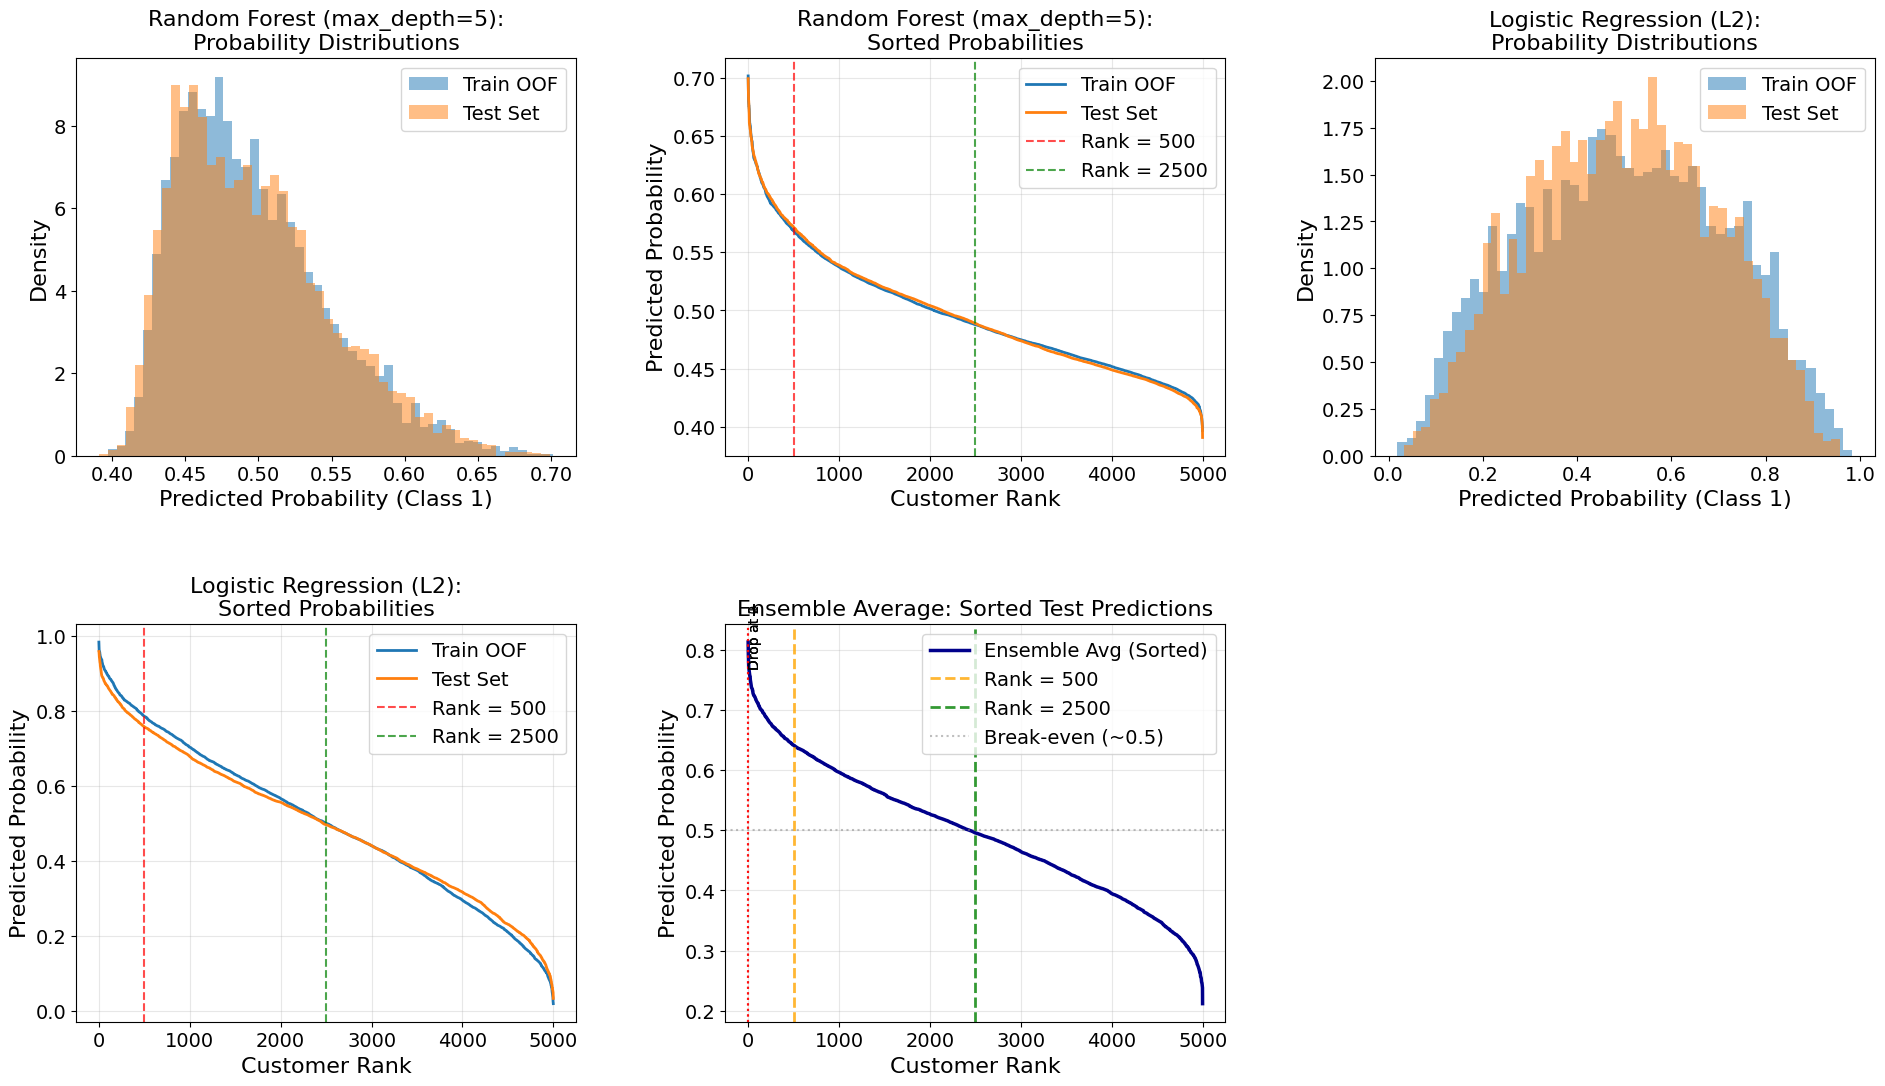

#### predicting test probabilities

In [33]:
test_x = pd.read_csv(f'{INPUT_DATA_DIR}x_test.txt', sep=r'\s+')
test_x_subset = test_x[features_to_keep]

In [34]:
if best_combo_features is not None:
    final_pipeline_qda = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', QuadraticDiscriminantAnalysis())
    ])
    
    final_pipeline_qda.fit(data_x[best_combo_features], y_flat)
    
    test_probs_qda = final_pipeline_qda.predict_proba(test_x[best_combo_features])[:, 1]
    
    test_output_df_qda = pd.DataFrame({
        'index': np.arange(len(test_probs_qda)),
        'predicted_probability': test_probs_qda
    })
    test_output_df_qda.to_csv(f'{OUTPUT_PREDS_DIR}test_predictions_qda.csv', index=False)
    print(f"\nTest set predictions for QDA saved to {OUTPUT_PREDS_DIR}test_predictions_qda.csv'.") 


Test set predictions for QDA saved to ./predictions/test_predictions_qda.csv'.


#### final selection - ensemble
This approach uses a nested ensemble optimized specifically for a custom business profit metric:

**Inner Ensemble (Feature Pairs)**: For every combination of two top features, independent univariate QDA models are trained. Their predicted probabilities are then averaged to create a single "group" prediction.

**Outer Ensemble (Profit Optimization)**: The predictions from all feature pairs are combined using a weighted average. The optimal weights are discovered via Random Search (200,000 iterations using a Dirichlet distribution) to find the exact combination that yields the highest net business profit.

In [35]:
import itertools
import numpy as np
import pandas as pd
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict

best_combo_features = ['V342', 'V191', 'V215', 'V483', 'V380'] 
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

subsets_of_2 = list(itertools.combinations(best_combo_features, 2))
ensemble_of_ensembles_probs = []

for parent_subset in subsets_of_2:
    print(f"Processing parent subset: {parent_subset}")
    
    oof_probs_group = []
    for feature in parent_subset:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', QuadraticDiscriminantAnalysis())
        ])
        probs = cross_val_predict(
            pipeline, data_x[[feature]], data_y, 
            cv=skf, method='predict_proba'
        )[:, 1]
        oof_probs_group.append(probs)
    
    group_ensemble = np.mean(oof_probs_group, axis=0)
    ensemble_of_ensembles_probs.append(group_ensemble)

all_group_probs = np.array(ensemble_of_ensembles_probs).T 

best_profit = -np.inf
best_weights = None

for _ in range(200000):
    weights = np.random.dirichlet(np.ones(len(subsets_of_2)), size=1)[0]
    ensemble_probs = np.dot(all_group_probs, weights)
    
    profit, _, _ = calculate_optimal_business_score(
        data_y, ensemble_probs, k_features=5, feature_cost=200
    )
    
    if profit > best_profit:
        best_profit = profit
        best_weights = weights

print(f"\nOptimal Weights found: {best_weights}")
print(f"Maximum Net Profit (Nested Univariate/Pair Approach): €{best_profit:,.1f}")

Processing parent subset: ('V342', 'V191')
Processing parent subset: ('V342', 'V215')
Processing parent subset: ('V342', 'V483')
Processing parent subset: ('V342', 'V380')
Processing parent subset: ('V191', 'V215')
Processing parent subset: ('V191', 'V483')
Processing parent subset: ('V191', 'V380')
Processing parent subset: ('V215', 'V483')
Processing parent subset: ('V215', 'V380')
Processing parent subset: ('V483', 'V380')

Optimal Weights found: [0.11444344 0.02758683 0.16086062 0.14652548 0.17362025 0.01445041
 0.15461713 0.09533537 0.02007434 0.09248612]
Maximum Net Profit (Nested Univariate/Pair Approach): €5,595.0


Optimal Weights found: [0.11444344 0.02758683 0.16086062 0.14652548 0.17362025 0.01445041
 0.15461713 0.09533537 0.02007434 0.09248612]

##### re-initialisation of the final ensemble

In [42]:
import itertools
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_predict

best_combo_features = ['V342', 'V191', 'V215', 'V483', 'V380']
subsets_of_2 = list(itertools.combinations(best_combo_features, 2))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
optimal_weights = np.array([0.11444344, 0.02758683, 0.16086062, 0.14652548, 0.17362025, 0.01445041,
 0.15461713, 0.09533537, 0.02007434, 0.09248612])
ensemble_of_ensembles_probs = []

for parent_subset in subsets_of_2:
    oof_probs_group = []
    for feature in parent_subset:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', QuadraticDiscriminantAnalysis())
        ])

        probs = cross_val_predict(
            pipeline, data_x[[feature]], data_y, 
            cv=skf, method='predict_proba'
        )[:, 1]
        oof_probs_group.append(probs)

    ensemble_of_ensembles_probs.append(np.mean(oof_probs_group, axis=0))

all_group_probs = np.array(ensemble_of_ensembles_probs).T 
final_ensemble_probs = np.dot(all_group_probs, optimal_weights)

final_profit, _, _ = calculate_optimal_business_score(
    data_y, final_ensemble_probs, k_features=5, feature_cost=200
)

print(f"Final Ensemble Net Profit: €{final_profit:,.2f}")

Final Ensemble Net Profit: €5,595.00


In [43]:
df_results = pd.DataFrame({
    'y_true': data_y.values if hasattr(data_y, 'values') else data_y,
    'y_prob': final_ensemble_probs
})
df_results.to_csv(f'{OUTPUT_PREDS_DIR}ensemble_predictions_oof.csv', index=False)
print(f"Predictions saved to {OUTPUT_PREDS_DIR}ensemble_predictions_oof.csv")

Predictions saved to ./predictions/ensemble_predictions_oof.csv


##### checking if profit threshold changed

In [44]:
profit_contacts, profit_thresh, max_profit, cum_profits = find_threshold_max_profit(y_flat, final_ensemble_probs, 10, 5)


sorted_probs_desc = np.sort(final_ensemble_probs)[::-1]
contacts_33_threshold = np.sum(sorted_probs_desc >= 0.3333) 

y_true_sorted = np.ravel(y_flat)[np.argsort(final_ensemble_probs)[::-1]]
cum_tps = np.cumsum(y_true_sorted == 1)

print("-" * 40)
print("--- Threshold Results ---")
print(f"Max Profit Threshold : {profit_contacts} contacts | P = {profit_thresh * 100:.2f}%")
print(f"Theoretical P=33.33% : {contacts_33_threshold} contacts")
print("-" * 40)

----------------------------------------
--- Threshold Results ---
Max Profit Threshold : 4235 contacts | P = 46.68%
Theoretical P=33.33% : 5000 contacts
----------------------------------------


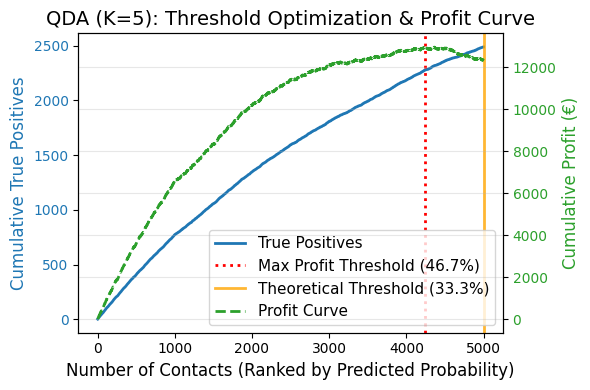

In [45]:
contacts_arr = np.arange(1, len(y_flat) + 1)

fig, ax1 = plt.subplots(figsize=(6, 4))

color1 = 'tab:blue'
ax1.set_xlabel('Number of Contacts (Ranked by Predicted Probability)', fontsize=12)
ax1.set_ylabel('Cumulative True Positives', color=color1, fontsize=12)
ax1.plot(contacts_arr, cum_tps, color=color1, linewidth=2, label='True Positives')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()  
color2 = 'tab:green'
ax2.set_ylabel('Cumulative Profit (€)', color=color2, fontsize=12)  
ax2.plot(contacts_arr, cum_profits, color=color2, linewidth=2, linestyle='--', label='Profit Curve')
ax2.tick_params(axis='y', labelcolor=color2)

ax1.axvline(x=profit_contacts, color='red', linestyle=':', linewidth=2,
            label=f'Max Profit Threshold ({profit_thresh * 100:.1f}%)')
ax1.axvline(x=contacts_33_threshold, color='orange', linestyle='-', linewidth=2, alpha=0.8,
            label=f'Theoretical Threshold (33.3%)')

plt.title("QDA (K=5): Threshold Optimization & Profit Curve", fontsize=14)
fig.tight_layout()

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower right', fontsize=11)

plt.grid(True, alpha=0.3)
plt.show()

##### ensemble calibration

We can see that in this ensemble setup, the maximum profit threshold has increased. This makes sense as ensembling shifts predicted probabilities toward the center, as seen in the next cell. We use Platt's Scaling to calibrate the final ensemble.

1. Generating uncalibrated OOF predictions...
2. Calibrating OOF predictions (Zero Leakage)...
Clean Calibrated Ensemble Net Profit (Train OOF): €5,580.00
3. Training base models on full training data...
4. Calibrating final test predictions...
Saved final test predictions to ./predictions/calibrated_ensemble_test_predictions.csv'
5. Generating Comparison Histograms...


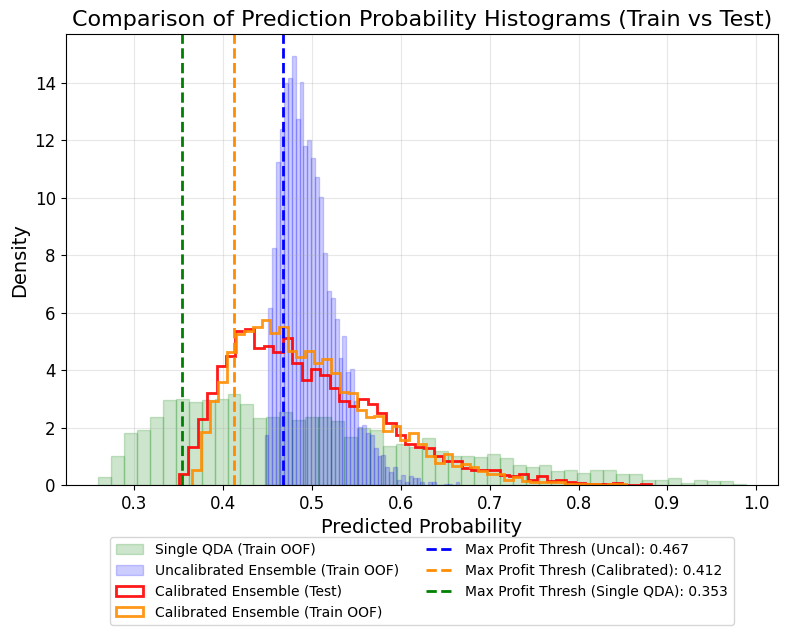

In [56]:
best_combo_features = ['V342', 'V191', 'V215', 'V483', 'V380']
subsets_of_2 = list(itertools.combinations(best_combo_features, 2))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
optimal_weights = np.array([0.11444344, 0.02758683, 0.16086062, 0.14652548, 0.17362025, 0.01445041,
 0.15461713, 0.09533537, 0.02007434, 0.09248612])

print("1. Generating uncalibrated OOF predictions...")
ensemble_of_ensembles_probs = []

for parent_subset in subsets_of_2:
    oof_probs_group = []
    for feature in parent_subset:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', QuadraticDiscriminantAnalysis())
        ])
        
        probs = cross_val_predict(
            pipeline, data_x[[feature]], data_y, 
            cv=skf, method='predict_proba', n_jobs=-1
        )[:, 1]
        oof_probs_group.append(probs)
    
    ensemble_of_ensembles_probs.append(np.mean(oof_probs_group, axis=0))

all_group_probs = np.array(ensemble_of_ensembles_probs).T 
uncalibrated_train_preds = np.dot(all_group_probs, optimal_weights)

df_train_uncalibrated = pd.DataFrame({'y_prob': uncalibrated_train_preds})
df_train_uncalibrated.to_csv(f'{OUTPUT_PREDS_DIR}ensemble_predictions_uncalibrated.csv', index=False)

print("2. Calibrating OOF predictions (Zero Leakage)...")
X_calib_train = uncalibrated_train_preds.reshape(-1, 1)

calibrated_train_oof_preds = cross_val_predict(
    LogisticRegression(), 
    X_calib_train, 
    data_y, 
    cv=skf, 
    method='predict_proba',
    n_jobs=-1
)[:, 1]

df_train_calibrated = pd.DataFrame({'probability': calibrated_train_oof_preds})
df_train_calibrated.to_csv(f'{OUTPUT_PREDS_DIR}calibrated_ensemble_train_oof.csv', index=False)

try:
    final_profit, gross_profit, contacts = calculate_optimal_business_score(
        data_y, calibrated_train_oof_preds, k_features=5, max_contacts=1000,
        threshold=0.33, tp_reward=10, fp_penalty=5, feature_cost=200
    )
    print(f"Clean Calibrated Ensemble Net Profit (Train OOF): €{final_profit:,.2f}")
except NameError:
    print("Profit calculation skipped (calculate_optimal_business_score not defined).")

print("3. Training base models on full training data...")
test_ensemble_of_ensembles_probs = []

for parent_subset in subsets_of_2:
    test_probs_group = []
    for feature in parent_subset:
        final_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', QuadraticDiscriminantAnalysis())
        ])
        
        final_pipeline.fit(data_x[[feature]], data_y)
        test_probs = final_pipeline.predict_proba(test_x[[feature]])[:, 1]
        test_probs_group.append(test_probs)
        
    test_ensemble_of_ensembles_probs.append(np.mean(test_probs_group, axis=0))

all_test_group_probs = np.array(test_ensemble_of_ensembles_probs).T
uncalibrated_test_preds = np.dot(all_test_group_probs, optimal_weights)

print("4. Calibrating final test predictions...")
platt_scaler = LogisticRegression()
platt_scaler.fit(X_calib_train, data_y)

X_calib_test = uncalibrated_test_preds.reshape(-1, 1)
calibrated_test_preds = platt_scaler.predict_proba(X_calib_test)[:, 1]

df_test_calibrated = pd.DataFrame({
    'index': np.arange(len(calibrated_test_preds)),
    'predicted_probability': calibrated_test_preds
})
df_test_calibrated.to_csv(f'{OUTPUT_PREDS_DIR}calibrated_ensemble_test_predictions.csv', index=False)
print(f"Saved final test predictions to {OUTPUT_PREDS_DIR}calibrated_ensemble_test_predictions.csv'")

print("5. Generating Comparison Histograms...")

try:
    df_qda = pd.read_csv(f'{OUTPUT_PREDS_DIR}train_oof_probabilities_qda.csv')
    qda_preds = df_qda['probability'].values
except FileNotFoundError:
    print("Single QDA file not found. Generating dummy data for visualization purposes.")
    qda_preds = np.random.beta(0.5, 0.5, size=len(data_y)) 

try:
    # Assuming your function returns (threshold, profit)
    thresh_uncal = find_threshold_max_profit(data_y, uncalibrated_train_preds, 10, 5)[1]
    thresh_cal = find_threshold_max_profit(data_y, calibrated_train_oof_preds, 10, 5)[1]
    thresh_single = find_threshold_max_profit(data_y, oof_probs, 10, 5)[1]
except NameError:
    print("find_threshold_max_profit not defined. Using dummy thresholds.")
    thresh_uncal, thresh_cal = 0.45, 0.30

plt.figure(figsize=(8, 6.5))

plt.hist(qda_preds, bins=50, color='green', alpha=0.2, 
         density=True, label='Single QDA (Train OOF)', edgecolor='green')

plt.hist(uncalibrated_train_preds, bins=50, color='blue', alpha=0.2, 
         density=True, label='Uncalibrated Ensemble (Train OOF)', edgecolor='blue')

plt.hist(calibrated_test_preds, bins=50, color='red', alpha=0.9, 
         density=True, label='Calibrated Ensemble (Test)', 
         histtype='step', linewidth=2)

plt.hist(calibrated_train_oof_preds, bins=50, color='darkorange', alpha=0.9, 
         density=True, label='Calibrated Ensemble (Train OOF)', 
         histtype='step', linewidth=2, linestyle='-')

plt.axvline(x=thresh_uncal, color='blue', linestyle='--', linewidth=2, 
            label=f'Max Profit Thresh (Uncal): {thresh_uncal:.3f}')

plt.axvline(x=thresh_cal, color='darkorange', linestyle='--', linewidth=2, 
            label=f'Max Profit Thresh (Calibrated): {thresh_cal:.3f}')

plt.axvline(x=thresh_single, color='green', linestyle='--', linewidth=2, 
            label=f'Max Profit Thresh (Single QDA): {thresh_single:.3f}')


plt.title('Comparison of Prediction Probability Histograms (Train vs Test)', fontsize=16)
plt.xlabel('Predicted Probability', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(alpha=0.3)

plt.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

plt.tight_layout()
plt.show()

The calibration of the ensemble's predictions is done on the same folds that the individual qda models were trained on. This creates a minor data leak because the base models generating those predictions already saw the holdout targets, however as the ensembling method is quite complex itself, it doesn't have that much impact. Additionally, this is an accepted industry shortcut because the calibrator (Platt Scaling) is mathematically too simple to overfit the leaked data, thereby preserving your predictions' rank order while saving massive computational time compared to strict nested cross-validation.

#### final selection of up to 1000 indexes - enselmble
Based on the threshold and the limit of 1000 indexes to select, we select them from the ensemble test results

In [60]:

group_id = "329822_STUDENT2ID_STUDENT3ID"

# 1. Export the observation indices (the 1000 customer indices)
try:
    # Ensure selected_test_indices is capped at 1000
    if len(selected_test_indices) > 1000:
        selected_test_indices = selected_test_indices[:1000]
        
    # Write to STUDENT1ID_STUDENT2ID_STUDENT3ID_obs.txt
    # The requirement asks for the indices; saving them line by line
    with open(f'{group_id}_obs.txt', 'w') as f:
        for idx in selected_test_indices:
            f.write(f"{idx}\n")
    print(f"Successfully saved {len(selected_test_indices)} indices to {group_id}_obs.txt")
    
except Exception as e:
    print(f"Error saving observations: {e}")

# 2. Export the variable names (the features used by the model)
try:
    # Write to STUDENT1ID_STUDENT2ID_STUDENT3ID_vars.txt
    with open(f'{group_id}_vars.txt', 'w') as f:
        for feature in best_combo_features:
            f.write(f"{feature}\n")
    print(f"Successfully saved features to {group_id}_vars.txt")
    
except Exception as e:
    print(f"Error saving features: {e}")

Successfully saved 1000 indices to 329822_STUDENT2ID_STUDENT3ID_obs.txt
Successfully saved features to 329822_STUDENT2ID_STUDENT3ID_vars.txt


#### class balance check

Loading data...
Train shape: (5000, 500), Test shape: (5000, 500)

Evaluating Random Forest (max_depth=5)...

Evaluating Logistic Regression (L2)...

Computing ensemble average of Test predictions...

Visualizations saved to 'test_prior_analysis.png'


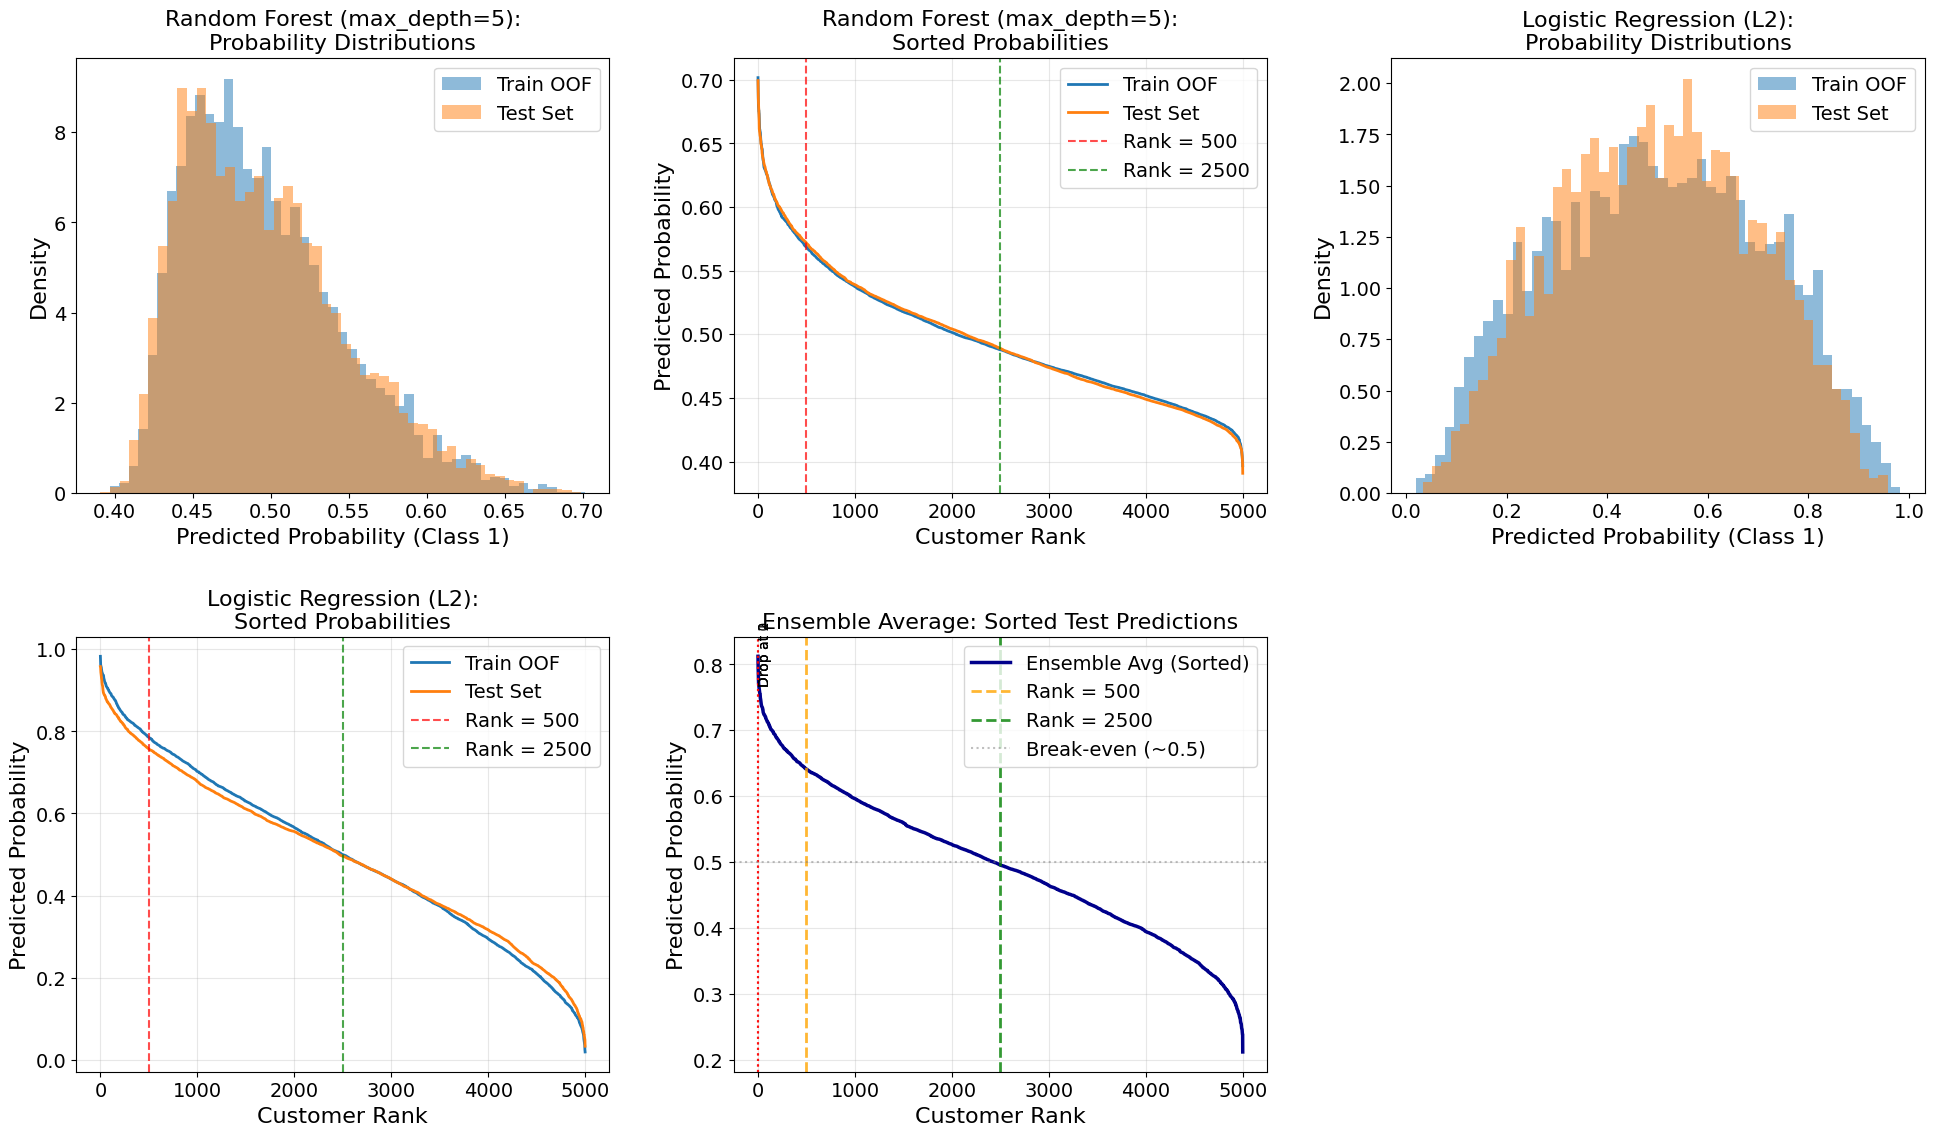

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
import warnings

warnings.filterwarnings('ignore')

print("Loading data...")
X_train = np.loadtxt(f'{INPUT_DATA_DIR}x_train.txt', skiprows=1)
y_train = np.loadtxt(f'{INPUT_DATA_DIR}y_train.txt', skiprows=1)
X_test = np.loadtxt(f'{INPUT_DATA_DIR}x_test.txt', skiprows=1)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

models = {
    'Random Forest (max_depth=5)': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1),
    'Logistic Regression (L2)': make_pipeline(StandardScaler(), LogisticRegression(C=0.1, max_iter=1000, random_state=42))
}

plt.figure(figsize=(20, 12))

all_test_preds = []

FS_TITLE = 16
FS_LABEL = 16
FS_TICK = 14
FS_LEGEND = 14

for i, (name, model) in enumerate(models.items()):
    print(f"\nEvaluating {name}...")
    
    train_oof_preds = cross_val_predict(model, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1)[:, 1]
    model.fit(X_train, y_train)
    test_preds = model.predict_proba(X_test)[:, 1]
    all_test_preds.append(test_preds)
    
    # Plot 1: Histogram
    plt.subplot(2, 3, i*2 + 1)
    plt.hist(train_oof_preds, bins=50, alpha=0.5, density=True, label='Train OOF')
    plt.hist(test_preds, bins=50, alpha=0.5, density=True, label='Test Set')
    plt.title(f'{name}:\nProbability Distributions', fontsize=FS_TITLE)
    plt.xlabel('Predicted Probability (Class 1)', fontsize=FS_LABEL)
    plt.ylabel('Density', fontsize=FS_LABEL)
    plt.tick_params(axis='both', which='major', labelsize=FS_TICK)
    plt.legend(fontsize=FS_LEGEND)
    
    # Plot 2: Waterfall
    plt.subplot(2, 3, i*2 + 2)
    plt.plot(np.sort(train_oof_preds)[::-1], label='Train OOF', linewidth=2)
    plt.plot(np.sort(test_preds)[::-1], label='Test Set', linewidth=2)
    plt.title(f'{name}:\nSorted Probabilities', fontsize=FS_TITLE)
    plt.xlabel('Customer Rank', fontsize=FS_LABEL)
    plt.ylabel('Predicted Probability', fontsize=FS_LABEL)
    plt.tick_params(axis='both', which='major', labelsize=FS_TICK)
    plt.axvline(x=500, color='r', linestyle='--', alpha=0.7, label='Rank = 500')
    plt.axvline(x=2500, color='g', linestyle='--', alpha=0.7, label='Rank = 2500')
    plt.grid(alpha=0.3)
    plt.legend(fontsize=FS_LEGEND)

# Plot 3: Ensemble
print("\nComputing ensemble average of Test predictions...")
ensemble_test_preds = np.mean(all_test_preds, axis=0)
sorted_ensemble_preds = np.sort(ensemble_test_preds)[::-1]

plt.subplot(2, 3, 5)
plt.plot(sorted_ensemble_preds, linewidth=2.5, color='darkblue', label='Ensemble Avg (Sorted)')

derivative = np.diff(sorted_ensemble_preds)
threshold_drop = np.percentile(np.abs(derivative), 90)
drops = np.where(np.abs(derivative) > threshold_drop)[0]

if len(drops) > 0:
    for drop_idx in drops[:3]:
        plt.axvline(x=drop_idx, color='red', linestyle=':', alpha=0.6)
        plt.text(drop_idx, sorted_ensemble_preds[0] * 0.95, f'Drop at {drop_idx}', rotation=90, fontsize=10)

plt.axvline(x=500, color='orange', linestyle='--', alpha=0.8, linewidth=2, label='Rank = 500')
plt.axvline(x=2500, color='green', linestyle='--', alpha=0.8, linewidth=2, label='Rank = 2500')
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Break-even (~0.5)')

plt.title('Ensemble Average: Sorted Test Predictions', fontsize=FS_TITLE)
plt.xlabel('Customer Rank', fontsize=FS_LABEL)
plt.ylabel('Predicted Probability', fontsize=FS_LABEL)
plt.tick_params(axis='both', which='major', labelsize=FS_TICK)
plt.grid(alpha=0.3)
plt.legend(fontsize=FS_LEGEND)

plt.tight_layout(pad=3.0)
#plt.savefig('test_prior_analysis.png', format='png', dpi=300)
print("\nVisualizations saved to 'test_prior_analysis.png'")